In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
admissions = pd.read_csv("admissions_clean.csv")
departments = pd.read_csv("departments_clean.csv")
patients=pd.read_csv("patients_clean.csv")

In [3]:
patients.head()

,Patient_ID,Gender,Age,Diagnosis,Anomaly_Flag
0,P00001,Female,82,Fever,False
1,P00002,Male,31,Diabetes,False
2,P00003,Male,15,Fever,False
3,P00004,Female,50,Asthma,False
4,P00005,Female,17,Diabetes,False


In [4]:
departments.head()

,department_id,department_name
0,D001,Cardiology
1,D002,Neurology
2,D003,Orthopedics
3,D004,Pediatrics
4,D005,Oncology


In [5]:
admissions.dtypes

Admission_ID           object
Patient_ID             object
Doctor_ID              object
Department_ID          object
Admission_Date         object
Discharge_Date         object
Status                 object
Length_of_Stay_Days     int64
dtype: object

In [6]:
admissions.head()

,Admission_ID,Patient_ID,Doctor_ID,Department_ID,Admission_Date,Discharge_Date,Status,Length_of_Stay_Days
0,A00001,P00001,DR00186,D002,2025-10-20,2025-10-28,Critical,8
1,A00002,P00002,DR00281,D019,2025-01-21,2025-01-23,Recovered,2
2,A00003,P00003,DR00105,D020,2025-06-24,2025-07-03,Discharged,9
3,A00004,P00004,DR00312,D004,2025-07-23,2025-07-25,Critical,2
4,A00005,P00005,DR00430,D018,2025-04-06,2025-04-07,Under Treatment,1


In [7]:
print("Admissions Shape:", admissions.shape)
print("Departments Shape:", departments.shape)
print("Patients Shape:", patients.shape)

Admissions Shape: (5000, 8)
Departments Shape: (20, 2)
Patients Shape: (5000, 5)


In [8]:
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   department_id    20 non-null     object
 1   department_name  20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


In [9]:
dept_admissions = admissions.merge(
    departments,
    left_on="Department_ID",
    right_on="department_id",
    how="left"
)

In [10]:
dept_admissions = dept_admissions.merge(
    patients,
    on="Patient_ID",
    how="left"
)

In [11]:
dept_admissions.head()

,Admission_ID,Patient_ID,Doctor_ID,Department_ID,Admission_Date,Discharge_Date,Status,Length_of_Stay_Days,department_id,department_name,Gender,Age,Diagnosis,Anomaly_Flag
0,A00001,P00001,DR00186,D002,2025-10-20,2025-10-28,Critical,8,D002,Neurology,Female,82,Fever,False
1,A00002,P00002,DR00281,D019,2025-01-21,2025-01-23,Recovered,2,D019,Endocrinology,Male,31,Diabetes,False
2,A00003,P00003,DR00105,D020,2025-06-24,2025-07-03,Discharged,9,D020,Dental,Male,15,Fever,False
3,A00004,P00004,DR00312,D004,2025-07-23,2025-07-25,Critical,2,D004,Pediatrics,Female,50,Asthma,False
4,A00005,P00005,DR00430,D018,2025-04-06,2025-04-07,Under Treatment,1,D018,Ophthalmology,Female,17,Diabetes,False


In [12]:
dept_admissions.shape

(5000, 14)

In [13]:
dept_admissions = dept_admissions.drop(columns=["department_id"])

In [14]:
dept_admissions.head()

,Admission_ID,Patient_ID,Doctor_ID,Department_ID,Admission_Date,Discharge_Date,Status,Length_of_Stay_Days,department_name,Gender,Age,Diagnosis,Anomaly_Flag
0,A00001,P00001,DR00186,D002,2025-10-20,2025-10-28,Critical,8,Neurology,Female,82,Fever,False
1,A00002,P00002,DR00281,D019,2025-01-21,2025-01-23,Recovered,2,Endocrinology,Male,31,Diabetes,False
2,A00003,P00003,DR00105,D020,2025-06-24,2025-07-03,Discharged,9,Dental,Male,15,Fever,False
3,A00004,P00004,DR00312,D004,2025-07-23,2025-07-25,Critical,2,Pediatrics,Female,50,Asthma,False
4,A00005,P00005,DR00430,D018,2025-04-06,2025-04-07,Under Treatment,1,Ophthalmology,Female,17,Diabetes,False


In [15]:
dept_admissions.shape

(5000, 13)

In [16]:
dept_admissions.describe()

,Length_of_Stay_Days,Age
count,5000.000000,5000.000000
mean,5.515400,45.734400
std,2.863669,26.080496
min,1.000000,1.000000
25%,3.000000,23.000000
50%,6.000000,46.000000
75%,8.000000,68.000000
max,10.000000,90.000000


In [17]:
dept_admissions.describe(include="object")

,Admission_ID,Patient_ID,Doctor_ID,Department_ID,Admission_Date,Discharge_Date,Status,department_name,Gender,Diagnosis
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,5000,5000,500,20,301,309,4,20,2,4
top,A00001,P00001,DR00039,D015,2025-05-12,2025-04-07,Critical,Emergency,Female,Cancer
freq,1,1,21,335,29,28,1279,335,2519,1280


In [18]:
dept_admissions["Status"].value_counts()

Status
Critical           1279
Under Treatment    1272
Recovered          1235
Discharged         1214
Name: count, dtype: int64

In [19]:
# ---------------------------------------------
#  Analyze Department-wise Patient Load
# Count the total number of patient admissions
# in each department and rank them from highest
# to lowest.
# ---------------------------------------------

dept_patient_load = dept_admissions.groupby("department_name")["Admission_ID"] \
                                   .count() \
                                   .sort_values(ascending=False)

print(dept_patient_load)

department_name
Emergency           335
Oncology            331
Orthopedics         320
Endocrinology       319
Pulmonology         317
Pediatrics          277
Ophthalmology       268
Radiology           266
Gastroenterology    260
Psychiatry          253
ICU                 253
Dental              253
Cardiology          233
Nephrology          218
ENT                 215
Neurology           200
Dermatology         179
General Surgery     175
Urology             169
Gynecology          159
Name: Admission_ID, dtype: int64


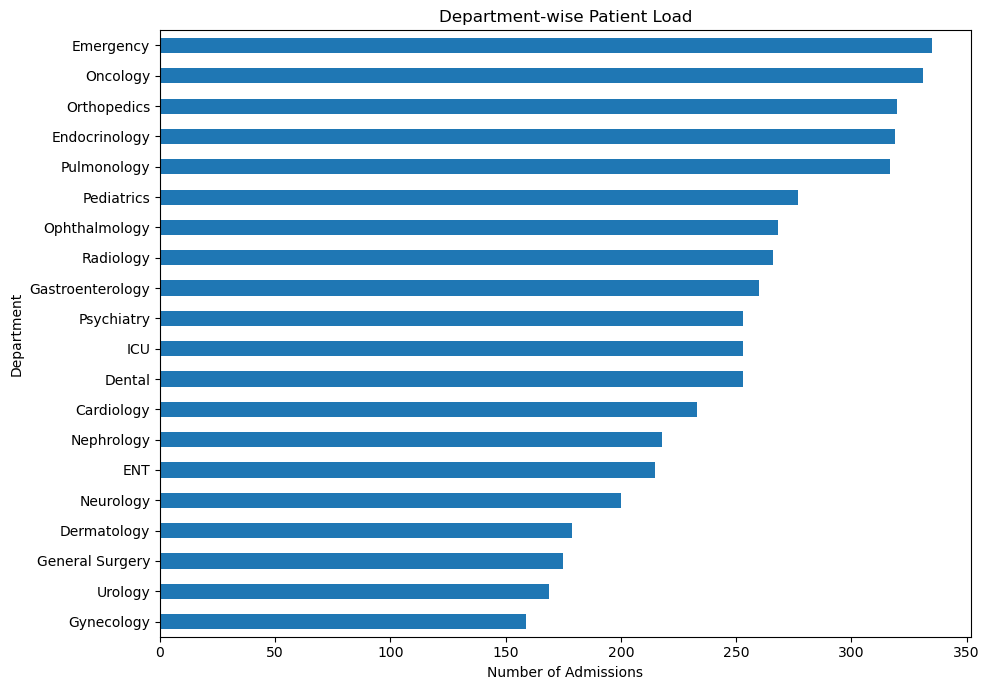

In [20]:
# Visualization: Department-wise Patient Load

plt.figure(figsize=(10, 7))

dept_patient_load.sort_values().plot(kind="barh")

plt.title("Department-wise Patient Load")
plt.xlabel("Number of Admissions")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

In [22]:
# : Analyze the average length of stay (LOS) for patients in each department.
avg_los = dept_admissions.groupby("department_name")["Length_of_Stay_Days"] \
                         .mean() \
                         .sort_values(ascending=False)

print(avg_los)

department_name
Nephrology          5.894495
Endocrinology       5.667712
ICU                 5.660079
Psychiatry          5.652174
Emergency           5.611940
Dermatology         5.592179
Radiology           5.571429
Urology             5.568047
Dental              5.561265
Pediatrics          5.541516
ENT                 5.516279
Orthopedics         5.500000
Ophthalmology       5.451493
Neurology           5.435000
Gynecology          5.427673
Oncology            5.398792
Cardiology          5.390558
General Surgery     5.354286
Gastroenterology    5.334615
Pulmonology         5.211356
Name: Length_of_Stay_Days, dtype: float64


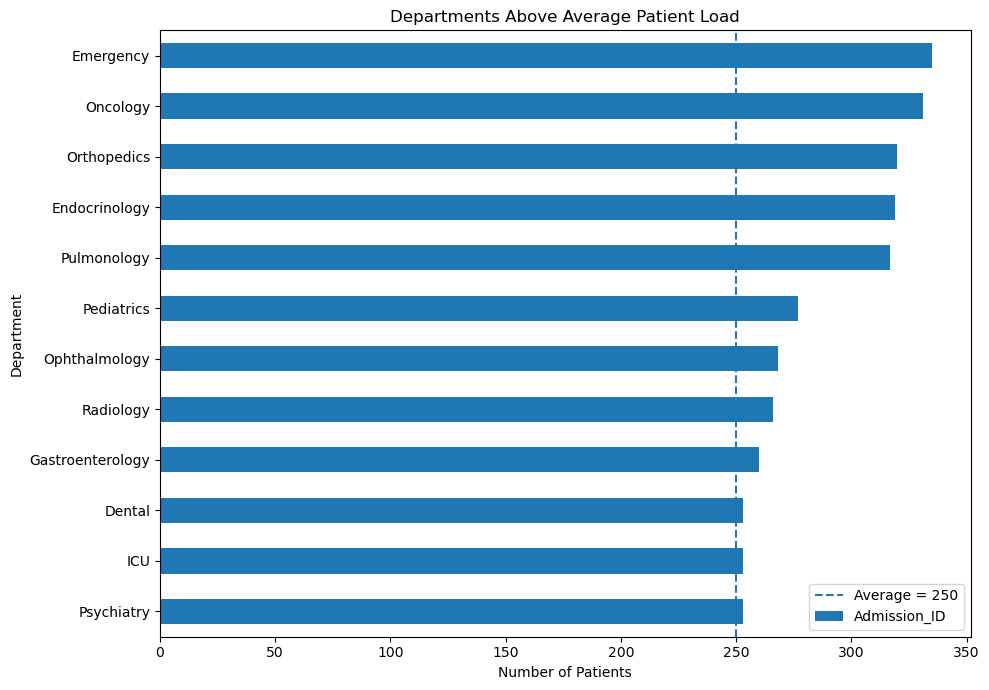

In [57]:
# Visualization: Departments Above Average Patient Load

above_average = dept_patient_load[dept_patient_load > avg_load]

plt.figure(figsize=(10, 7))

above_average.sort_values().plot(kind="barh")

plt.axvline(
    avg_load,
    linestyle="--",
    label=f"Average = {avg_load:.0f}"
)

plt.title("Departments Above Average Patient Load")
plt.xlabel("Number of Patients")
plt.ylabel("Department")
plt.legend()

plt.tight_layout()
plt.show()

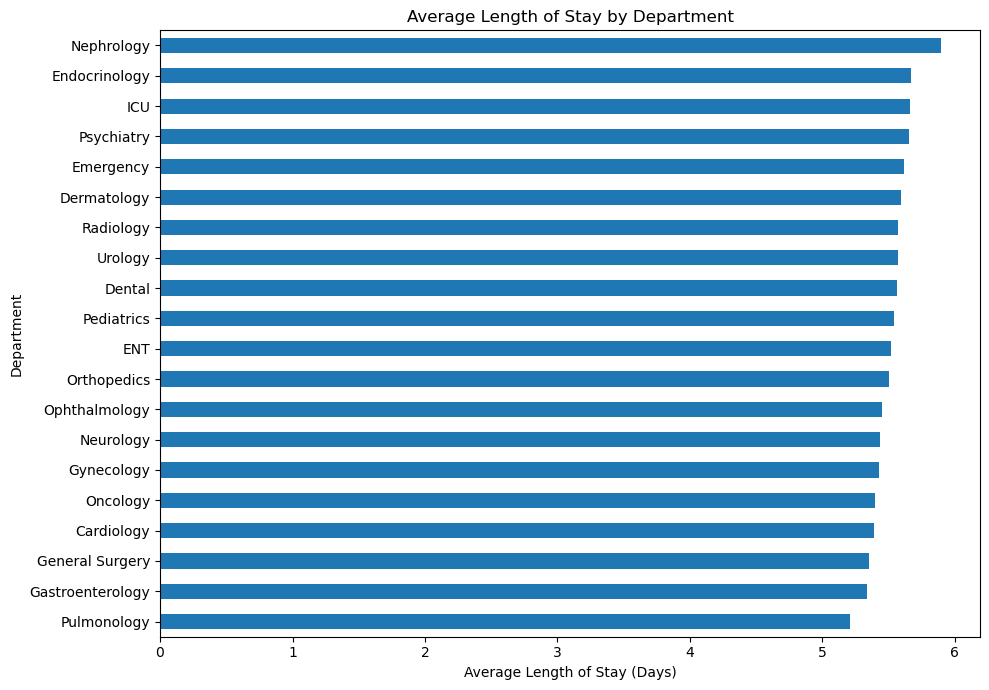

In [23]:
# Visualization: Average Length of Stay by Department

plt.figure(figsize=(10, 7))

avg_los.sort_values().plot(kind="barh")

plt.title("Average Length of Stay by Department")
plt.xlabel("Average Length of Stay (Days)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

In [24]:
#  Analyze the distribution of patient status (Critical, Recovered, Discharged, Under Treatment) across departments.
pd.crosstab(
    dept_admissions["department_name"],
    dept_admissions["Status"]
)

Status,Critical,Discharged,Recovered,Under Treatment
department_name,,,,
Cardiology,69,39,54,71
Dental,69,62,69,53
Dermatology,53,43,40,43
ENT,53,59,49,54
Emergency,87,75,91,82
Endocrinology,70,89,70,90
Gastroenterology,63,65,60,72
General Surgery,40,38,54,43
Gynecology,34,34,50,41


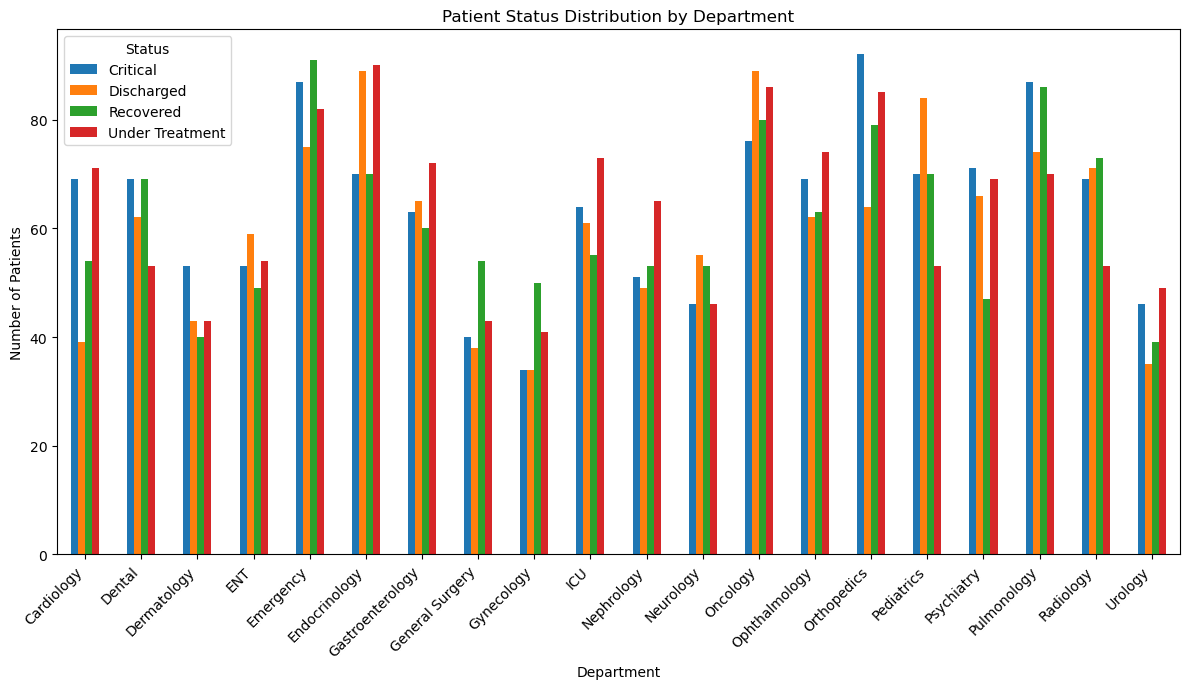

In [25]:
status_by_department = pd.crosstab(
    dept_admissions["department_name"],
    dept_admissions["Status"]
)

status_by_department.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Patient Status Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

In [58]:
# Calculate the average patient load across all departments
avg_load = dept_admissions.groupby("department_name")["Admission_ID"].count().mean()
print("Average Patient Load:", avg_load)

dept_patient_load[dept_patient_load > avg_load]

Average Patient Load: 250.0


department_name
Emergency           335
Oncology            331
Orthopedics         320
Endocrinology       319
Pulmonology         317
Pediatrics          277
Ophthalmology       268
Radiology           266
Gastroenterology    260
Psychiatry          253
ICU                 253
Dental              253
Name: Admission_ID, dtype: int64

In [59]:
# Calculate the percentage contribution of each department to the total patient load
patient_percentage = (
    dept_admissions["department_name"]
    .value_counts(normalize=True) * 100
).sort_values(ascending=False)

print(patient_percentage)

department_name
Emergency           6.70
Oncology            6.62
Orthopedics         6.40
Endocrinology       6.38
Pulmonology         6.34
Pediatrics          5.54
Ophthalmology       5.36
Radiology           5.32
Gastroenterology    5.20
ICU                 5.06
Psychiatry          5.06
Dental              5.06
Cardiology          4.66
Nephrology          4.36
ENT                 4.30
Neurology           4.00
Dermatology         3.58
General Surgery     3.50
Urology             3.38
Gynecology          3.18
Name: proportion, dtype: float64


In [60]:
#  Identify departments with highest number of critical patients
critical_patients = (
    dept_admissions[dept_admissions["Status"] == "Critical"]
    .groupby("department_name")["Admission_ID"]
    .count()
    .sort_values(ascending=False)
)

print(critical_patients)

department_name
Orthopedics         92
Emergency           87
Pulmonology         87
Oncology            76
Psychiatry          71
Pediatrics          70
Endocrinology       70
Cardiology          69
Radiology           69
Dental              69
Ophthalmology       69
ICU                 64
Gastroenterology    63
Dermatology         53
ENT                 53
Nephrology          51
Neurology           46
Urology             46
General Surgery     40
Gynecology          34
Name: Admission_ID, dtype: int64


In [29]:
#  Identify departments with the highest number of patients currently under treatment.
under_treatment = (
    dept_admissions[dept_admissions["Status"] == "Under Treatment"]
    .groupby("department_name")["Admission_ID"]
    .count()
    .sort_values(ascending=False)
)

print(under_treatment)

department_name
Endocrinology       90
Oncology            86
Orthopedics         85
Emergency           82
Ophthalmology       74
ICU                 73
Gastroenterology    72
Cardiology          71
Pulmonology         70
Psychiatry          69
Nephrology          65
ENT                 54
Dental              53
Pediatrics          53
Radiology           53
Urology             49
Neurology           46
General Surgery     43
Dermatology         43
Gynecology          41
Name: Admission_ID, dtype: int64


In [61]:
# Calculate the critical patient rate for each department
critical_rate = (
    dept_admissions.groupby("department_name")["Status"]
    .apply(lambda x: (x == "Critical").mean() * 100)
    .sort_values(ascending=False)
)

print(critical_rate.round(2))

department_name
Cardiology          29.61
Dermatology         29.61
Orthopedics         28.75
Psychiatry          28.06
Pulmonology         27.44
Dental              27.27
Urology             27.22
Emergency           25.97
Radiology           25.94
Ophthalmology       25.75
ICU                 25.30
Pediatrics          25.27
ENT                 24.65
Gastroenterology    24.23
Nephrology          23.39
Neurology           23.00
Oncology            22.96
General Surgery     22.86
Endocrinology       21.94
Gynecology          21.38
Name: Status, dtype: float64


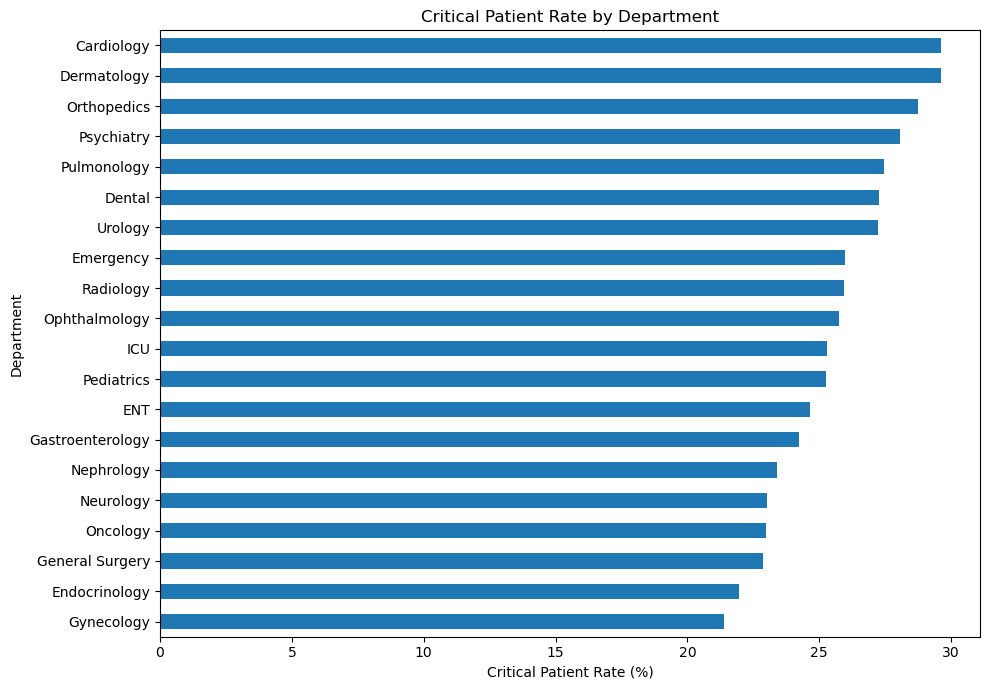

In [56]:
# Visualization: Critical Patient Rate by Department

critical_rate = (
    dept_admissions.groupby("department_name")["Status"]
    .apply(lambda x: (x == "Critical").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))

critical_rate.sort_values().plot(kind="barh")

plt.title("Critical Patient Rate by Department")
plt.xlabel("Critical Patient Rate (%)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [62]:
#  Create a department wise summary of patient load and average length of stay
eda_summary = dept_admissions.groupby("department_name").agg(
    Patient_Load=("Admission_ID", "count"),
    Avg_LOS=("Length_of_Stay_Days", "mean")
).sort_values("Patient_Load", ascending=False)

print(eda_summary)

                  Patient_Load   Avg_LOS
department_name                         
Emergency                  335  5.611940
Oncology                   331  5.398792
Orthopedics                320  5.500000
Endocrinology              319  5.667712
Pulmonology                317  5.211356
Pediatrics                 277  5.541516
Ophthalmology              268  5.451493
Radiology                  266  5.571429
Gastroenterology           260  5.334615
Psychiatry                 253  5.652174
ICU                        253  5.660079
Dental                     253  5.561265
Cardiology                 233  5.390558
Nephrology                 218  5.894495
ENT                        215  5.516279
Neurology                  200  5.435000
Dermatology                179  5.592179
General Surgery            175  5.354286
Urology                    169  5.568047
Gynecology                 159  5.427673


In [32]:
#  Identify the number of recovered patients in each department.
recovered = (
    dept_admissions[dept_admissions["Status"] == "Recovered"]
    .groupby("department_name")["Admission_ID"]
    .count()
    .sort_values(ascending=False)
)

print(recovered)

department_name
Emergency           91
Pulmonology         86
Oncology            80
Orthopedics         79
Radiology           73
Endocrinology       70
Pediatrics          70
Dental              69
Ophthalmology       63
Gastroenterology    60
ICU                 55
Cardiology          54
General Surgery     54
Nephrology          53
Neurology           53
Gynecology          50
ENT                 49
Psychiatry          47
Dermatology         40
Urology             39
Name: Admission_ID, dtype: int64


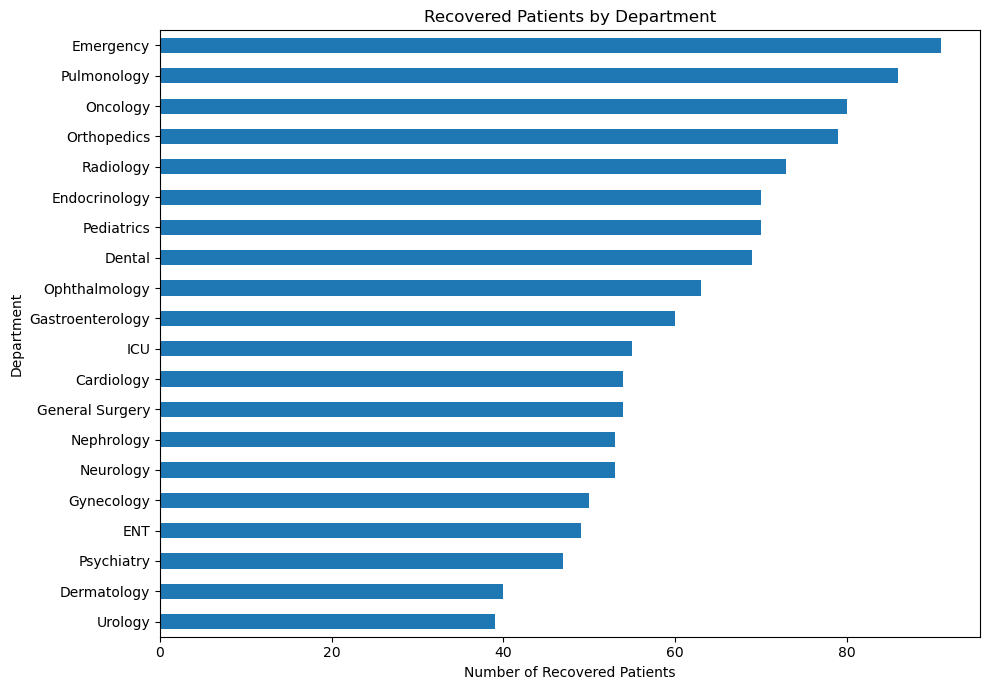

In [52]:
# Visualization: Recovered Patients by Department

plt.figure(figsize=(10, 7))

recovered.sort_values().plot(kind="barh")

plt.title("Recovered Patients by Department")
plt.xlabel("Number of Recovered Patients")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [33]:
#  Identify departments with the highest workload based on Critical and Under Treatment patients.
high_workload = (
    dept_admissions[
        dept_admissions["Status"].isin(["Critical", "Under Treatment"])
    ]
    .groupby("department_name")["Admission_ID"]
    .count()
    .sort_values(ascending=False)
)

print(high_workload)

department_name
Orthopedics         177
Emergency           169
Oncology            162
Endocrinology       160
Pulmonology         157
Ophthalmology       143
Cardiology          140
Psychiatry          140
ICU                 137
Gastroenterology    135
Pediatrics          123
Radiology           122
Dental              122
Nephrology          116
ENT                 107
Dermatology          96
Urology              95
Neurology            92
General Surgery      83
Gynecology           75
Name: Admission_ID, dtype: int64


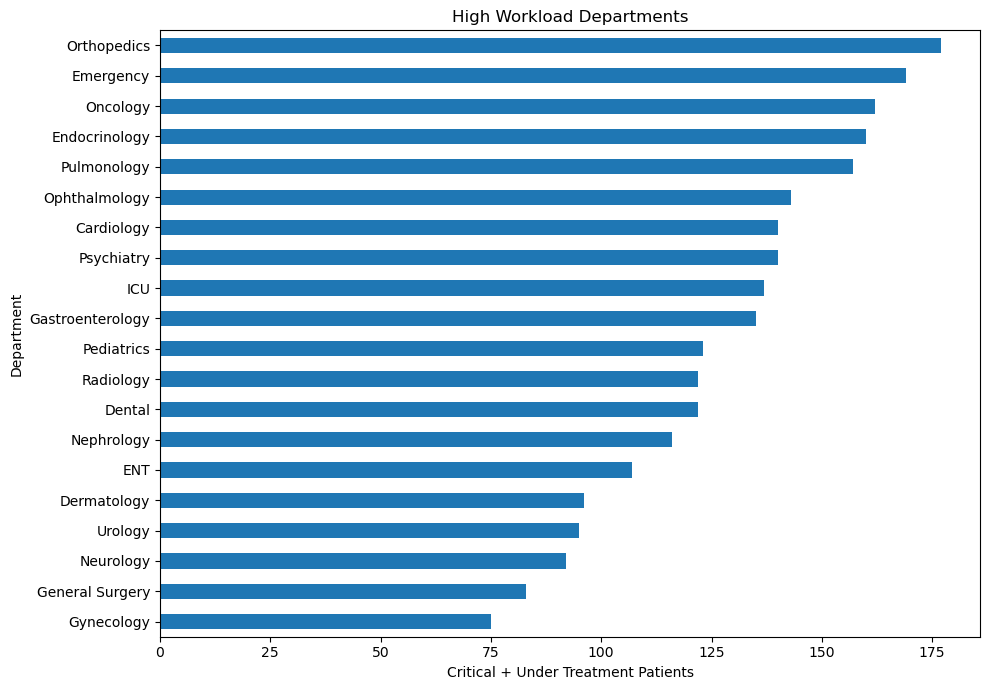

In [53]:
# Visualization: High Workload Departments

plt.figure(figsize=(10, 7))

high_workload.sort_values().plot(kind="barh")

plt.title("High Workload Departments")
plt.xlabel("Critical + Under Treatment Patients")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [34]:
#  Analyze patient distribution across departments based on age groups.
dept_admissions["Age_Group"] = pd.cut(
    dept_admissions["Age"],
    bins=[0,18,35,50,65,100],
    labels=["0-18","19-35","36-50","51-65","66+"]
)

pd.crosstab(
    dept_admissions["department_name"],
    dept_admissions["Age_Group"]
)

Age_Group,0-18,19-35,36-50,51-65,66+
department_name,,,,,
Cardiology,55,45,32,45,56
Dental,48,36,45,45,79
Dermatology,38,39,24,26,52
ENT,51,39,35,33,57
Emergency,60,58,64,57,96
Endocrinology,65,57,53,57,87
Gastroenterology,50,61,40,36,73
General Surgery,48,31,12,29,55
Gynecology,23,37,26,30,43


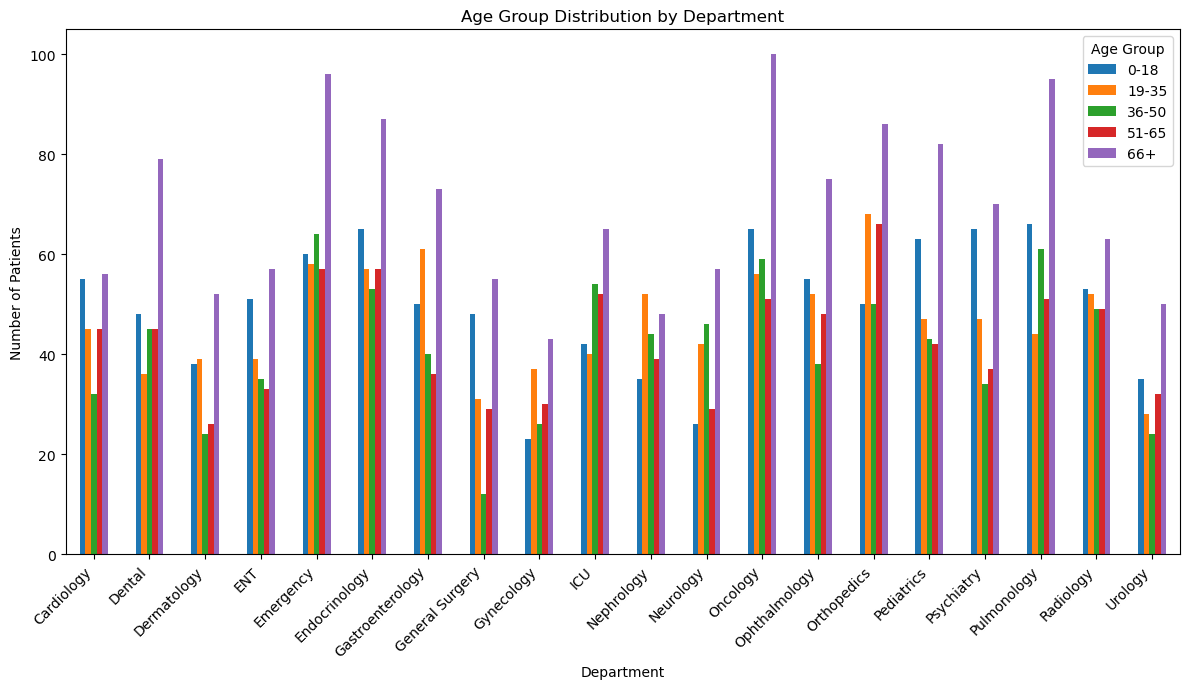

In [49]:
# Visualization: Age Group Distribution by Department

age_by_department = pd.crosstab(
    dept_admissions["department_name"],
    dept_admissions["Age_Group"]
)

age_by_department.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Age Group Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

In [50]:
#  Analyze patient distribution across departments based on gender groups.
pd.crosstab(
    dept_admissions["department_name"],
    dept_admissions["Gender"]
)

Gender,Female,Male
department_name,,
Cardiology,119,114
Dental,118,135
Dermatology,106,73
ENT,103,112
Emergency,169,166
Endocrinology,133,186
Gastroenterology,144,116
General Surgery,106,69
Gynecology,77,82


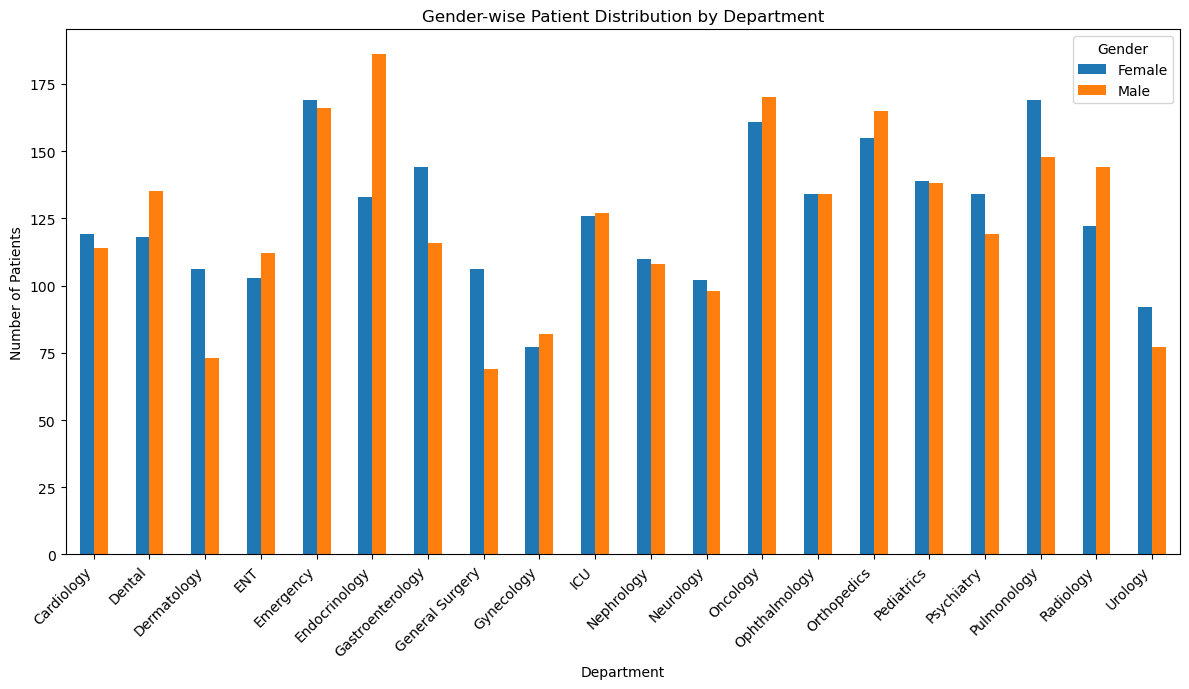

In [51]:
# Visualization: Gender-wise Patient Distribution

gender_data = pd.crosstab(
    dept_admissions["department_name"],
    dept_admissions["Gender"]
)

gender_data.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Gender-wise Patient Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

In [36]:
# EDA 21: Analyze patient distribution across departments based on diagnosis.
pd.crosstab(
    dept_admissions["department_name"],
    dept_admissions["Diagnosis"]
)

Diagnosis,Asthma,Cancer,Diabetes,Fever
department_name,,,,
Cardiology,52,59,61,61
Dental,63,67,65,58
Dermatology,36,51,46,46
ENT,58,56,49,52
Emergency,68,84,99,84
Endocrinology,76,84,81,78
Gastroenterology,73,75,63,49
General Surgery,43,49,33,50
Gynecology,48,37,40,34


In [37]:

dept_admissions.groupby("department_name")["Age"] \
.mean() \
.sort_values(ascending=False)

department_name
Dental              48.035573
ICU                 47.509881
Gynecology          47.440252
Neurology           47.035000
Oncology            46.963746
Emergency           46.805970
Orthopedics         46.709375
Urology             46.615385
Pulmonology         46.397476
Endocrinology       45.796238
Ophthalmology       45.712687
Pediatrics          45.361011
Dermatology         45.145251
Nephrology          44.669725
Gastroenterology    44.446154
Radiology           44.263158
Cardiology          44.124464
ENT                 43.660465
General Surgery     43.628571
Psychiatry          43.138340
Name: Age, dtype: float64

In [38]:
#  Calculate the discharge rate for each department.
discharge_analysis = (
    dept_admissions
    .groupby("department_name")
    .agg(
        Total_Patients=("Admission_ID", "count"),
        Discharged_Patients=("Status", lambda x: (x == "Discharged").sum())
    )
)

discharge_analysis["Discharge_Rate (%)"] = (
    discharge_analysis["Discharged_Patients"] /
    discharge_analysis["Total_Patients"] * 100
).round(2)

discharge_analysis = discharge_analysis.sort_values(
    by="Discharge_Rate (%)",
    ascending=False
)

print(discharge_analysis)

                  Total_Patients  Discharged_Patients  Discharge_Rate (%)
department_name                                                          
Pediatrics                   277                   84               30.32
Endocrinology                319                   89               27.90
Neurology                    200                   55               27.50
ENT                          215                   59               27.44
Oncology                     331                   89               26.89
Radiology                    266                   71               26.69
Psychiatry                   253                   66               26.09
Gastroenterology             260                   65               25.00
Dental                       253                   62               24.51
ICU                          253                   61               24.11
Dermatology                  179                   43               24.02
Pulmonology                  317      

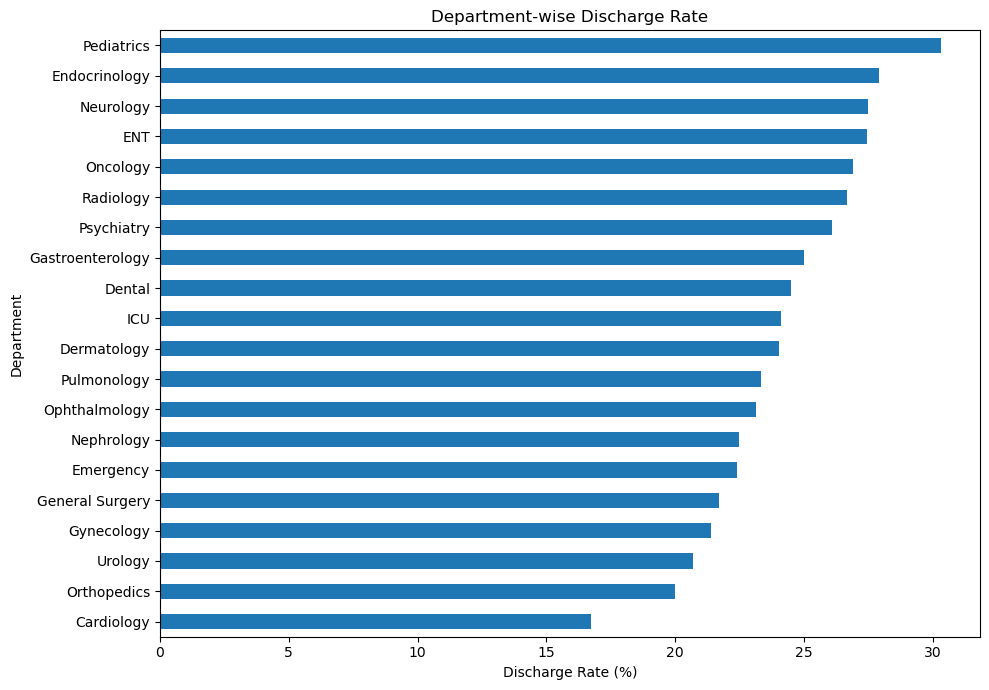

In [54]:
# Visualization: Department-wise Discharge Rate

plt.figure(figsize=(10, 7))

discharge_analysis["Discharge_Rate (%)"].sort_values().plot(
    kind="barh"
)

plt.title("Department-wise Discharge Rate")
plt.xlabel("Discharge Rate (%)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [76]:
# EDA: Analyze Admissions per Doctor by Department

doctor_workload = (
    dept_admissions
    .groupby("department_name")
    .agg(
        Patient_Load=("Admission_ID", "count"),
        Doctor_Count=("Doctor_ID", "nunique")
    )
)

doctor_workload["Admissions_Per_Doctor"] = (
    doctor_workload["Patient_Load"] /
    doctor_workload["Doctor_Count"]
).round(2)

doctor_workload = doctor_workload.sort_values(
    "Admissions_Per_Doctor",
    ascending=False
)

print(doctor_workload)

                  Patient_Load  Doctor_Count  Admissions_Per_Doctor
department_name                                                    
Pulmonology                317            29                  10.93
Orthopedics                320            30                  10.67
Dental                     253            24                  10.54
Pediatrics                 277            27                  10.26
ENT                        215            21                  10.24
Cardiology                 233            23                  10.13
ICU                        253            25                  10.12
Oncology                   331            33                  10.03
Neurology                  200            20                  10.00
Endocrinology              319            32                   9.97
Urology                    169            17                   9.94
Ophthalmology              268            27                   9.93
Nephrology                 218            22    

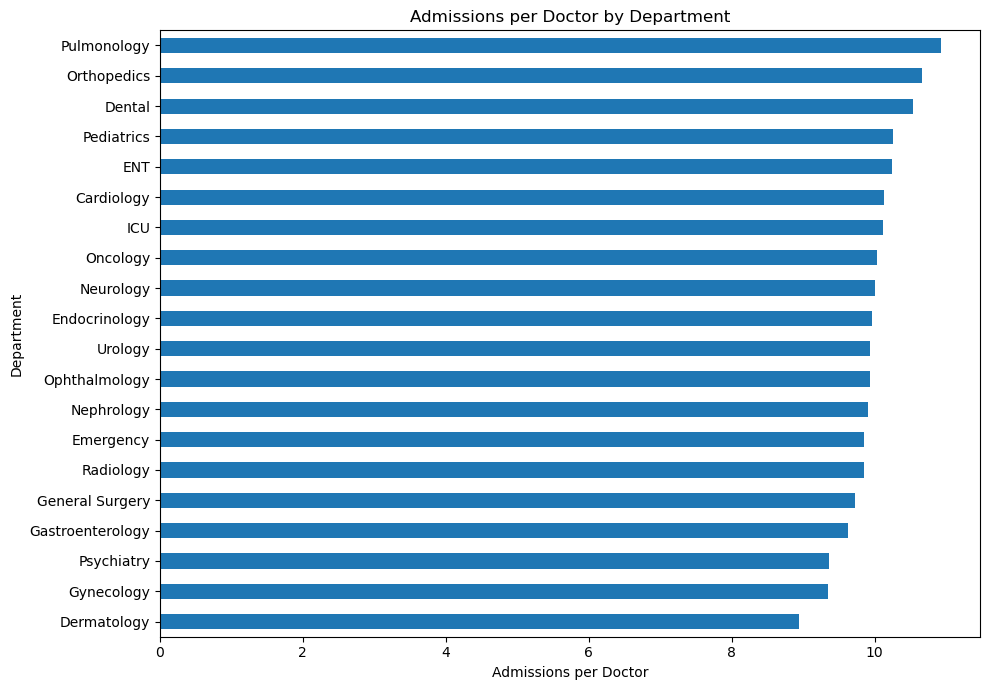

In [77]:
# Visualization: Admissions per Doctor by Department

plt.figure(figsize=(10, 7))

doctor_workload["Admissions_Per_Doctor"].sort_values().plot(
    kind="barh"
)

plt.title("Admissions per Doctor by Department")
plt.xlabel("Admissions per Doctor")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [39]:
# KPI 1: Total Number of Patient Admissions

total_admissions = dept_admissions["Admission_ID"].count()
print("Total Patient Admissions:", total_admissions)

Total Patient Admissions: 5000


In [40]:
# KPI 2: Total Number of Departments

total_departments = dept_admissions["department_name"].nunique()
print("Total Departments:", total_departments)

Total Departments: 20


In [41]:
# KPI 3: Average Patient Load per Department

avg_patient_load = dept_admissions.groupby("department_name")["Admission_ID"].count().mean()
print("Average Patient Load per Department:", round(avg_patient_load,2))

Average Patient Load per Department: 250.0


In [63]:
# KPI 4: Highest Patient Load Value

max_patient_load = dept_admissions["department_name"].value_counts().max()
print("Highest Patient Load:", max_patient_load)

Highest Patient Load: 335


In [64]:
# KPI 5: Department with the Highest Patient Load

highest_load = dept_admissions["department_name"].value_counts().head(1)
print(highest_load)

department_name
Emergency    335
Name: count, dtype: int64


In [44]:
# KPI 6: Average Length of Stay Across All Departments

avg_los = dept_admissions["Length_of_Stay_Days"].mean()
print("Average Length of Stay:", round(avg_los,2), "Days")

Average Length of Stay: 5.52 Days


In [45]:
# KPI 7: Overall Critical Patient Rate

critical_rate = (
    (dept_admissions["Status"] == "Critical").mean() * 100
)

print("Overall Critical Patient Rate:", round(critical_rate,2), "%")

Overall Critical Patient Rate: 25.58 %


In [46]:
# KPI 8: Overall Recovery Rate

recovery_rate = (
    (dept_admissions["Status"] == "Recovered").mean() * 100
)

print("Overall Recovery Rate:", round(recovery_rate,2), "%")

Overall Recovery Rate: 24.7 %


In [47]:
# KPI 9: Overall Discharge Rate

discharge_rate = (
    (dept_admissions["Status"] == "Discharged").mean() * 100
)

print("Overall Discharge Rate:", round(discharge_rate,2), "%")

Overall Discharge Rate: 24.28 %


In [48]:
# KPI 10: Department with the Highest Critical Patient Rate

highest_critical_rate = (
    dept_admissions.groupby("department_name")["Status"]
    .apply(lambda x: (x == "Critical").mean() * 100)
    .sort_values(ascending=False)
    .head(1)
)

print(highest_critical_rate.round(2))

department_name
Cardiology    29.61
Name: Status, dtype: float64


In [65]:
# KPI 11: Female Patient Count

female_count = (dept_admissions["Gender"] == "Female").sum()

print("Female Patients:", female_count)

Female Patients: 2519


In [66]:
# KPI 12: Male Patient Count

male_count = (dept_admissions["Gender"] == "Male").sum()

print("Male Patients:", male_count)

Male Patients: 2481


In [67]:
# KPI 13: Female Patient Percentage

female_percentage = (
    (dept_admissions["Gender"] == "Female").mean() * 100
)

print("Female Patient Percentage:", round(female_percentage, 2), "%")

Female Patient Percentage: 50.38 %


In [68]:
# KPI 14: Male Patient Percentage

male_percentage = (
    (dept_admissions["Gender"] == "Male").mean() * 100
)

print("Male Patient Percentage:", round(male_percentage, 2), "%")



Male Patient Percentage: 49.62 %


In [69]:
# KPI 15: Average Patient Age

average_age = dept_admissions["Age"].mean()

print("Average Patient Age:", round(average_age, 2), "years")

Average Patient Age: 45.73 years


In [70]:
# KPI 16: Youngest Patient Age

youngest_age = dept_admissions["Age"].min()

print("Youngest Patient Age:", youngest_age, "years")

Youngest Patient Age: 1 years


In [71]:
# KPI 17: Oldest Patient Age

oldest_age = dept_admissions["Age"].max()

print("Oldest Patient Age:", oldest_age, "years")

Oldest Patient Age: 90 years


In [72]:
# KPI 18: Median Patient Age

median_age = dept_admissions["Age"].median()

print("Median Patient Age:", median_age, "years")

Median Patient Age: 46.0 years


In [73]:
# KPI 19: Department with Highest Female Admissions

female_by_department = (
    dept_admissions[dept_admissions["Gender"] == "Female"]
    .groupby("department_name")["Admission_ID"]
    .count()
    .sort_values(ascending=False)
)

print("Department with Highest Female Admissions:")
print(female_by_department.head(1))

Department with Highest Female Admissions:
department_name
Pulmonology    169
Name: Admission_ID, dtype: int64


In [74]:
# KPI 20: Department with Highest Male Admissions

male_by_department = (
    dept_admissions[dept_admissions["Gender"] == "Male"]
    .groupby("department_name")["Admission_ID"]
    .count()
    .sort_values(ascending=False)
)

print("Department with Highest Male Admissions:")
print(male_by_department.head(1))

Department with Highest Male Admissions:
department_name
Endocrinology    186
Name: Admission_ID, dtype: int64


# Key Findings & KPI Summary

## Overall KPIs

- Total patient admissions: **5,000**
- Total departments: **20**
- Average patient load per department: **250 admissions**
- Highest patient load: **335 admissions**
- Average length of stay: **5.52 days**

## Department-wise Patient Load

- **Emergency** recorded the highest patient load with **335 admissions**.
- The average patient load across the 20 departments was **250 admissions**.
- Patient load varied across departments, indicating differences in admission demand.

## Patient Status

- Overall critical patient rate: **25.58%**
- Overall recovery rate: **24.70%**
- Overall discharge rate: **24.28%**
- **Cardiology** recorded the highest critical patient rate at **29.61%**.

## Gender Distribution

- Female patients: **2,519 (50.38%)**
- Male patients: **2,481 (49.62%)**
- The overall gender distribution was nearly balanced.
- **Pulmonology** recorded the highest number of female admissions with **169**.
- **Endocrinology** recorded the highest number of male admissions with **186**.

## Age Distribution

- Average patient age: **45.73 years**
- Median patient age: **46 years**
- Patient ages ranged from **1 to 90 years**.
- The average and median ages indicate that the typical patient age was around the mid-40s.

## Key Insights

- Emergency had the highest overall patient load among the departments.
- Cardiology showed the highest critical patient rate, indicating a relatively higher concentration of critical cases.
- Female and male admissions were almost evenly distributed overall.
- Age distribution shows a broad patient population, with an average age of approximately 46 years.